# **OpenEvolve Project**

***
***

## **Configurations**

### **Necessary imports:**

In [98]:
# Imports general
import os
import nest_asyncio2
import copy
import sympy as sp
import numpy as np
import importlib.util
#import scipy

# Imports openevolve
from openevolve import run_evolution, evolve_function
from openevolve.config import Config, LLMModelConfig
#from openevolve.api import _prepare_evaluator,_prepare_program

# Import NetworkX and Matplotlip
import networkx as nx
import matplotlib as plt

### **API Availability Call:**

In [ ]:
# Please use this setup to ensure that the chosen model is available before running any evolution process

from google import genai

client = genai.Client(api_key="YOUR KEY")

response = client.models.generate_content(
     model="gemini-3.1-flash-lite",
     contents="Explain how AI works in a few words"
)
print(response.text)

### **Set up Key & Notebook**

In [ ]:
# Set API KEY
os.environ["OPENAI_API_KEY"]= "YOUR KEY"

In [113]:
# Asyncio set up for notebook (This is important to synchronize OpenEvolve with a notebook!!!!)
nest_asyncio2.apply()

## **Project Idea: Coxeter Radicals**


### **Helper Functions**

In [ ]:
# Input: Adjacency matrix
# Output: Coxeter matrix

def Adj_to_Cox_matrix(adj_mat):
    Cox_mat = copy.copy(adj_mat)
    n = len(adj_mat)

    for i in range(0,n):
        for j in range(0,n):
            if i != j and Cox_mat[i,j] == 0:
                Cox_mat[i,j]= 2

            elif Cox_mat[i,j] == 1:
                Cox_mat[i,j] = 3

            elif i == j:
                Cox_mat[i,j] = 1

    return Cox_mat

In [ ]:
# Input: Coxeter matrix
# Output: Cosinus matrix

def Cox_to_Cos_matrix(Cox_mat):
    n = len(Cox_mat)
    Cos = sp.zeros(n,n)
    for i in range(n):
        for j in range(n):
            Cos[i,j] = (-sp.cos(sp.pi/Cox_mat[i][j]))
    
    return Cos#

In [ ]:
# Input: Graph
# Output: Radical Dimension of the to the graph associated Coxeter group

def radical_dim(G):
    adj_mat = nx.adjacency_matrix(G).toarray()
    n = len(adj_mat)

    # Adj-matrix to Cox-matrix
    Cox_mat = Adj_to_Cox_matrix(adj_mat)
    
    # Cox-matrix to Cos-matrix
    Cos_mat = Cox_to_Cos_matrix(Cox_mat)
    
    # Rank
    r = Cos_mat.rank()

    return n-r

### **Initial Example**

In [ ]:
# Imports the initial program 
path = "YOUR PATH TO initial_program.py"

spec = importlib.util.spec_from_file_location("mymodule", path)
module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(module)

G, num_v, num_e, sum = module.construct_graph()
num_v, num_e, sum

(13, 15, 28)

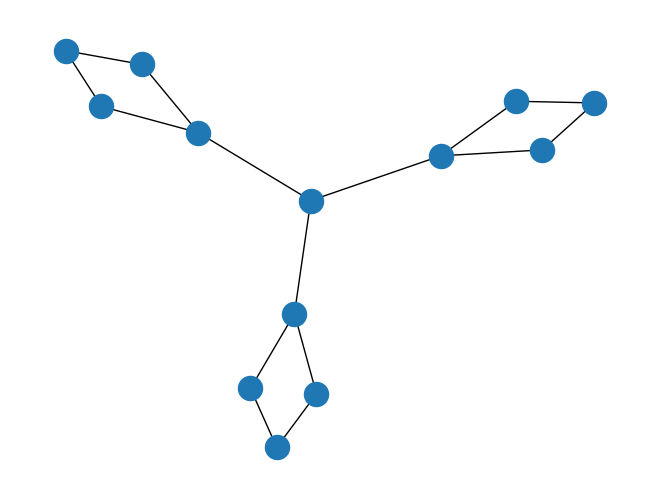

In [77]:
# Draw initial graph
nx.draw(G)

In [79]:
# The corresponding adjacency matrix
M = nx.adjacency_matrix(G)
M_alt = M.toarray()
M_alt

array([[0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
       [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
       [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0],
       [0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0]])

In [81]:
# Compute Coxeter matrix of the given Adjacency matrix
Cox_mat = Adj_to_Cox_matrix(M_alt)
Cox_mat

array([[1, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2],
       [3, 1, 2, 2, 3, 3, 2, 2, 2, 2, 2, 2, 2],
       [3, 2, 1, 2, 2, 2, 3, 3, 2, 2, 2, 2, 2],
       [3, 2, 2, 1, 2, 2, 2, 2, 3, 3, 2, 2, 2],
       [2, 3, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 3],
       [2, 3, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 3],
       [2, 2, 3, 2, 2, 2, 1, 2, 2, 2, 3, 2, 2],
       [2, 2, 3, 2, 2, 2, 2, 1, 2, 2, 3, 2, 2],
       [2, 2, 2, 3, 2, 2, 2, 2, 1, 2, 2, 3, 2],
       [2, 2, 2, 3, 2, 2, 2, 2, 2, 1, 2, 3, 2],
       [2, 2, 2, 2, 2, 2, 3, 3, 2, 2, 1, 2, 2],
       [2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 2, 1, 2],
       [2, 2, 2, 2, 3, 3, 2, 2, 2, 2, 2, 2, 1]])

In [83]:
# Compute the Cosinus matrix of the given Coxeter matrix
Cos_mat = Cox_to_Cos_matrix(Cox_mat)
Cos_mat

(Matrix([
 [   1, -1/2, -1/2, -1/2,    0,    0,    0,    0,    0,    0,    0,    0,    0],
 [-1/2,    1,    0,    0, -1/2, -1/2,    0,    0,    0,    0,    0,    0,    0],
 [-1/2,    0,    1,    0,    0,    0, -1/2, -1/2,    0,    0,    0,    0,    0],
 [-1/2,    0,    0,    1,    0,    0,    0,    0, -1/2, -1/2,    0,    0,    0],
 [   0, -1/2,    0,    0,    1,    0,    0,    0,    0,    0,    0,    0, -1/2],
 [   0, -1/2,    0,    0,    0,    1,    0,    0,    0,    0,    0,    0, -1/2],
 [   0,    0, -1/2,    0,    0,    0,    1,    0,    0,    0, -1/2,    0,    0],
 [   0,    0, -1/2,    0,    0,    0,    0,    1,    0,    0, -1/2,    0,    0],
 [   0,    0,    0, -1/2,    0,    0,    0,    0,    1,    0,    0, -1/2,    0],
 [   0,    0,    0, -1/2,    0,    0,    0,    0,    0,    1,    0, -1/2,    0],
 [   0,    0,    0,    0,    0,    0, -1/2, -1/2,    0,    0,    1,    0,    0],
 [   0,    0,    0,    0,    0,    0,    0,    0, -1/2, -1/2,    0,    1,    0],
 [   0,    0,    0

In [ ]:
# Compute the radical dimension of the given bilinear from (i.e. Cosinus matrix)
radical_dim(G)

## **Evolution Process**

In [ ]:
# Start the Evolution of the initial program (the initial graph)
result = run_evolution(
    initial_program="YOUR PATH TO initial_program.py",
    evaluator="YOUR PATH TO evaluator.py",
    config="YOUR PATH to config.yaml",
    output_dir="YOUR PATH",
    iterations=100,
    #config=config
)

## **Best program**

### **Visualization**

In [ ]:
# Imports the best program 
path = "YOUR PATH TO best_program.py"

spec = importlib.util.spec_from_file_location("mymodule", path)
module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(module)

G, num_v, num_e, sum = module.construct_graph()

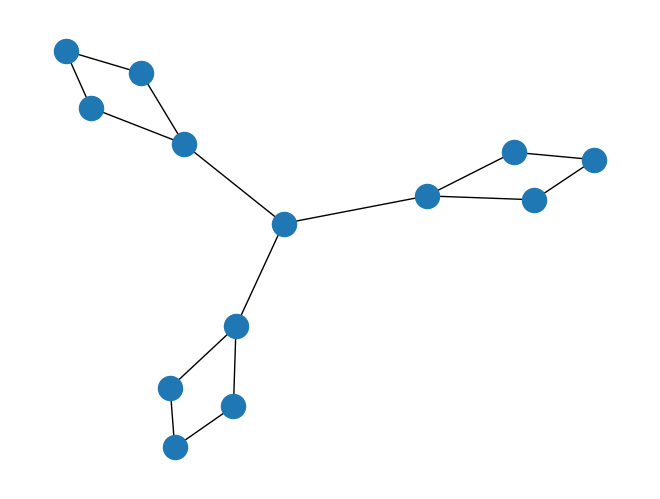

In [116]:
# Draw the best graph
nx.draw(G)

In [106]:
# Compute the radical dimension
radical_dim(G)

0